# 📊 Model Evaluation Report

This notebook visualizes the performance of our ML model for curriculum gap analysis.

**Model Details:**
- **Architecture:** Ensemble (LinearSVC + Logistic Regression + XGBoost)
- **Voting:** Soft voting with calibrated probabilities
- **Classes:** 18 job roles

In [1]:
import pickle
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Setup paths
BASE_DIR = os.path.dirname(os.getcwd())
sys.path.append(BASE_DIR)

MODEL_DIR = os.path.join(BASE_DIR, 'backend', 'ml_engine')
print(f"Model Directory: {MODEL_DIR}")

Model Directory: c:\Users\ASUS-Pc\Documents\LSPU Files\3rd Year\1st Sem\CSST 101\ml_finals\backend\ml_engine


## 1. Load Model Artifacts

In [2]:
# Load saved model, vectorizer, and label encoder
with open(os.path.join(MODEL_DIR, 'model.pkl'), 'rb') as f:
    model = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

print(f"✅ Model loaded successfully!")
print(f"\nClasses ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    print(f"  {i+1}. {cls}")

✅ Model loaded successfully!

Classes (18):
  1. AI Engineer
  2. Business Analyst
  3. Cloud Architect
  4. Content Specialist
  5. Cybersecurity Engineer
  6. Data Analyst
  7. Data Engineer
  8. DevOps Engineer
  9. Game Developer
  10. Mobile App Developer
  11. Network Engineer
  12. Project Manager
  13. QA Engineer
  14. Robotics Engineer
  15. Software Engineer
  16. UI/UX Designer
  17. Vibe Coder
  18. Web Developer


## 2. Classification Report

In [3]:
# Read the classification report
report_path = os.path.join(MODEL_DIR, 'classification_report.txt')
with open(report_path, 'r') as f:
    report = f.read()
print(report)

Accuracy: 80.27%

                        precision    recall  f1-score   support

           AI Engineer       1.00      0.98      0.99       209
      Business Analyst       0.04      0.25      0.07        16
       Cloud Architect       0.22      0.49      0.31        59
Cybersecurity Engineer       0.93      0.83      0.87       236
          Data Analyst       1.00      0.98      0.99       408
         Data Engineer       0.48      0.74      0.58        31
       DevOps Engineer       0.36      0.64      0.46        59
        Game Developer       0.11      0.52      0.18        23
  Mobile App Developer       0.99      0.89      0.94        74
      Network Engineer       1.00      0.94      0.97       434
       Project Manager       1.00      0.82      0.90       450
           QA Engineer       0.51      0.67      0.58        33
     Robotics Engineer       0.88      1.00      0.94       390
     Software Engineer       0.97      0.48      0.65       750
        UI/UX Designe

## 3. Per-Class Performance Visualization

In [4]:
# Parse the classification report into a DataFrame
lines = report.strip().split('\n')
data = []

for line in lines[3:-3]:  # Skip header and summary rows
    parts = line.split()
    if len(parts) >= 5:
        # Handle multi-word class names
        if parts[-4].replace('.', '').isdigit():
            role = ' '.join(parts[:-4])
            precision, recall, f1, support = parts[-4:]
        else:
            continue
        data.append({
            'Role': role,
            'Precision': float(precision),
            'Recall': float(recall),
            'F1-Score': float(f1),
            'Support': int(support)
        })

df_metrics = pd.DataFrame(data)
df_metrics = df_metrics.sort_values('F1-Score', ascending=True)
df_metrics

,Role,Precision,Recall,F1-Score,Support
15,Vibe Coder,0.00,0.00,0.00,0
1,Business Analyst,0.04,0.25,0.07,16
7,Game Developer,0.11,0.52,0.18,23
2,Cloud Architect,0.22,0.49,0.31,59
6,DevOps Engineer,0.36,0.64,0.46,59
5,Data Engineer,0.48,0.74,0.58,31
11,QA Engineer,0.51,0.67,0.58,33
14,UI/UX Designer,0.68,0.61,0.64,176
13,Software Engineer,0.97,0.48,0.65,750
3,Cybersecurity Engineer,0.93,0.83,0.87,236


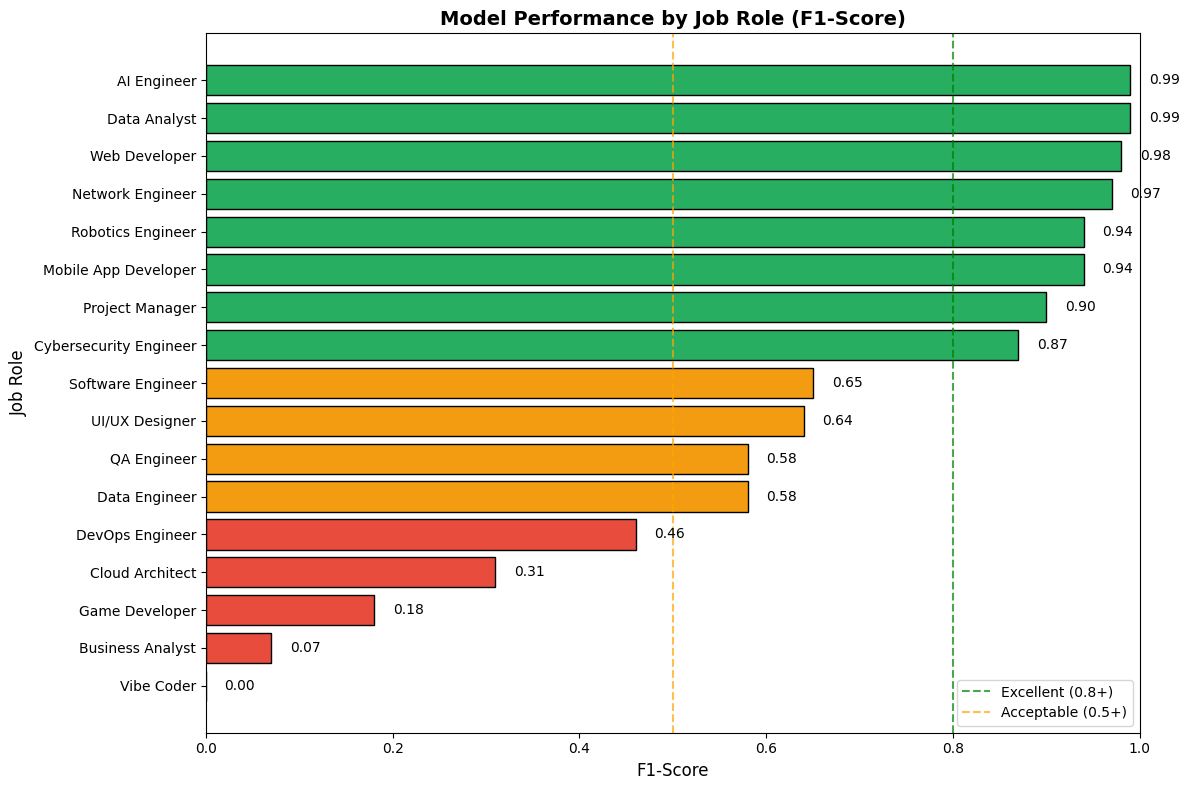

In [5]:
# F1-Score Bar Chart
plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x < 0.5 else '#f39c12' if x < 0.7 else '#27ae60' for x in df_metrics['F1-Score']]

bars = plt.barh(df_metrics['Role'], df_metrics['F1-Score'], color=colors, edgecolor='black')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.title('Model Performance by Job Role (F1-Score)', fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)

# Add value labels
for bar, val in zip(bars, df_metrics['F1-Score']):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

plt.axvline(x=0.8, color='green', linestyle='--', alpha=0.7, label='Excellent (0.8+)')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Acceptable (0.5+)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('f1_score_chart.png', dpi=150)
plt.show()

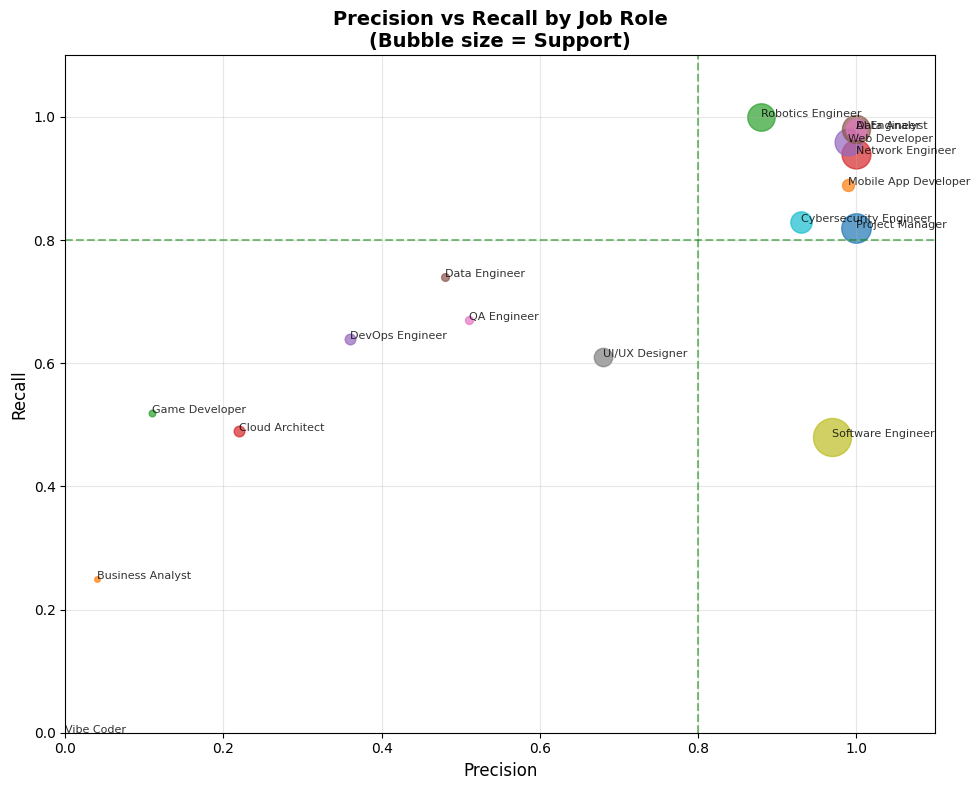

In [6]:
# Precision vs Recall Scatter Plot
plt.figure(figsize=(10, 8))

for i, row in df_metrics.iterrows():
    plt.scatter(row['Precision'], row['Recall'], s=row['Support'], alpha=0.7)
    plt.annotate(row['Role'], (row['Precision'], row['Recall']), fontsize=8, alpha=0.8)

plt.xlabel('Precision', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.title('Precision vs Recall by Job Role\n(Bubble size = Support)', fontsize=14, fontweight='bold')
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
plt.axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_scatter.png', dpi=150)
plt.show()

## 4. Top Performing Roles

In [7]:
# Top 5 and Bottom 5 performers
top5 = df_metrics.nlargest(5, 'F1-Score')[['Role', 'F1-Score', 'Support']]
bottom5 = df_metrics.nsmallest(5, 'F1-Score')[['Role', 'F1-Score', 'Support']]

print("🏆 TOP 5 PERFORMING ROLES")
print(top5.to_string(index=False))
print("\n⚠️ BOTTOM 5 PERFORMING ROLES")
print(bottom5.to_string(index=False))

🏆 TOP 5 PERFORMING ROLES
                Role  F1-Score  Support
        Data Analyst      0.99      408
         AI Engineer      0.99      209
       Web Developer      0.98      372
    Network Engineer      0.97      434
Mobile App Developer      0.94       74

⚠️ BOTTOM 5 PERFORMING ROLES
            Role  F1-Score  Support
      Vibe Coder      0.00        0
Business Analyst      0.07       16
  Game Developer      0.18       23
 Cloud Architect      0.31       59
 DevOps Engineer      0.46       59


## 5. Summary Statistics

In [8]:
# Extract accuracy from report
accuracy_line = [l for l in lines if 'accuracy' in l.lower()]
if accuracy_line:
    parts = accuracy_line[0].split()
    accuracy = float(parts[-2])
else:
    accuracy = 0.0

print("=" * 50)
print("📊 MODEL SUMMARY")
print("=" * 50)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Average F1-Score: {df_metrics['F1-Score'].mean():.2f}")
print(f"Total Test Samples: {df_metrics['Support'].sum()}")
print(f"Number of Classes: {len(df_metrics)}")
print(f"Roles with F1 >= 0.8: {len(df_metrics[df_metrics['F1-Score'] >= 0.8])}")
print(f"Roles with F1 < 0.5: {len(df_metrics[df_metrics['F1-Score'] < 0.5])}")
print("=" * 50)

ValueError: could not convert string to float: 'Accuracy:'